酒精饮料用户洞察报告——白酒、啤酒-1
https://report.iresearch.cn/report_pdf.aspx?id=4000

In [1]:
import matplotlib.pyplot as plt
# 设置中文字体支持
import matplotlib.font_manager as fm
# 备选中文字体列表
chinese_fonts = [
    "SimHei",           # Windows
    "Heiti TC",         # macOS
    "WenQuanYi Micro Hei",  # Linux
    "Microsoft YaHei",  # 微软雅黑
    "Arial Unicode MS", # 备选
]

# 获取系统可用字体
available_fonts = {f.name for f in fm.fontManager.ttflist}

# 查找第一个可用的中文字体
for font in chinese_fonts:
    if font in available_fonts:
        plt.rcParams["font.family"] = font
        break

plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

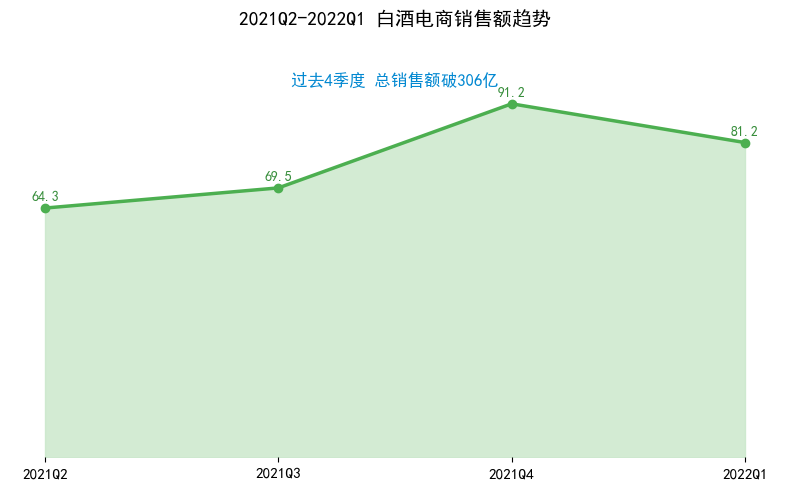

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# 数据定义
quarters = ["2021Q2", "2021Q3", "2021Q4", "2022Q1"]
sales = [64.3, 69.5, 91.2, 81.2]

# 坐标轴
x = np.arange(len(quarters))

# 创建画布
fig, ax = plt.subplots(figsize=(8, 5))

# 绘制渐变面积图
# 用fill_between创建底部渐变
ax.plot(x, sales, color="#4CAF50", linewidth=2.5, marker='o', label="销售额")
ax.fill_between(x, sales, color="#C8E6C9", alpha=0.8)

# 添加数据标注
for i, val in enumerate(sales):
    ax.text(x[i], val + 1.5, f"{val}", ha='center', va='bottom', fontsize=10, fontweight='bold', color="#388E3C")

# 添加总销售额说明文本
total_sales = sum(sales)
ax.text(0.5, 0.9, f"过去4季度 总销售额破{total_sales:.0f}亿",
        transform=ax.transAxes, fontsize=12, color='#0288D1', ha='center', va='bottom', fontweight='bold')

# 设置x轴
ax.set_xticks(x)
ax.set_xticklabels(quarters, fontsize=11)

# 隐藏y轴刻度线，仅设置范围
ax.set_yticks([])
ax.set_ylim(0, max(sales) + 15)

# 添加标题
ax.set_title("2021Q2-2022Q1 白酒电商销售额趋势", fontsize=14, fontweight="bold", pad=15)

# 美化：去除边框
for spine in ["top", "right", "bottom", "left"]:
    ax.spines[spine].set_visible(False)

# 网格线（增强阅读感）
ax.grid(axis='y', linestyle='--', alpha=0.2)

plt.tight_layout()
plt.show()


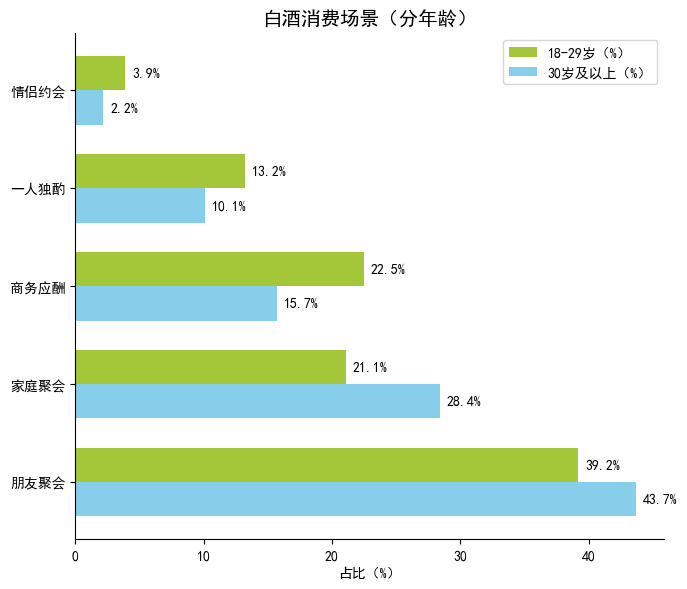

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# 消费场景
scenarios = ["朋友聚会", "家庭聚会", "商务应酬", "一人独酌", "情侣约会"]
# 18-29岁占比（%），数据与图表一致
age18_29 = [39.2, 21.1, 22.5, 13.2, 3.9]
# 30岁及以上占比（%），数据与图表一致
age30_up = [43.7, 28.4, 15.7, 10.1, 2.2]

# 创建画布和子图
fig, ax = plt.subplots(figsize=(7, 6))

# 绘制水平条形图（18-29岁，绿色）
y = np.arange(len(scenarios))
bar_width = 0.35
bars1 = ax.barh(y + bar_width/2, age18_29, height=bar_width, color="#A4C639", label="18-29岁（%）")
# 绘制水平条形图（30岁及以上，蓝色）
bars2 = ax.barh(y - bar_width/2, age30_up, height=bar_width, color="#87CEEB", label="30岁及以上（%）")

# 添加数据标注（18-29岁）
for bar in bars1:
    width = bar.get_width()
    ax.annotate(f'{width}%',
                xy=(width, bar.get_y() + bar.get_height() / 2),
                xytext=(5, 0),  # 标注位置调整
                textcoords="offset points",
                ha='left', va='center')

# 添加数据标注（30岁及以上）
for bar in bars2:
    width = bar.get_width()
    ax.annotate(f'{width}%',
                xy=(width, bar.get_y() + bar.get_height() / 2),
                xytext=(5, 0),  # 标注位置调整
                textcoords="offset points",
                ha='left', va='center')

# 绘制商务应酬、一人独酌的黄色虚线框
# 找到商务应酬和一人独酌的索引
start_idx = scenarios.index("商务应酬")
end_idx = scenarios.index("一人独酌")
# 计算框的坐标
y_min = y[start_idx] - bar_width/2 - 0.1
y_max = y[end_idx] + bar_width/2 + 0.1
x_min = 0
x_max = max(max(age18_29), max(age30_up)) + 5  # 适当扩展x轴范围

# 设置y轴刻度和标签
ax.set_yticks(y)
ax.set_yticklabels(scenarios)
# 设置x轴标签
ax.set_xlabel("占比（%）")
# 设置标题
ax.set_title("白酒消费场景（分年龄）", fontsize=14, fontweight="bold")

# 添加图例
ax.legend()

# 美化图表，隐藏顶部和右侧边框
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

plt.tight_layout()  # 自动调整布局
plt.show()

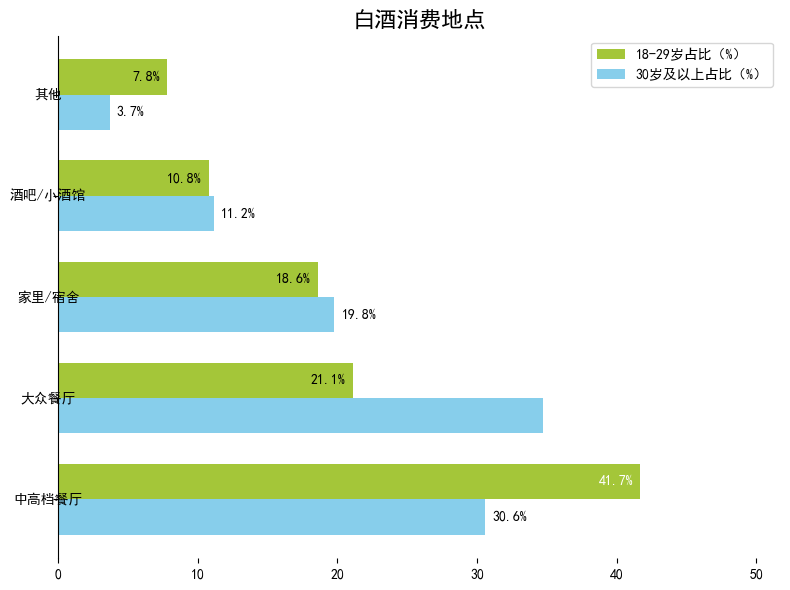

In [8]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Ellipse

# 消费地点
locations = ["中高档餐厅", "大众餐厅", "家里/宿舍", "酒吧/小酒馆", "其他"]
# 18-29岁占比（%），数据与图表一致
age18_29 = [41.7, 21.1, 18.6, 10.8, 7.8]
# 30岁及以上占比（%），数据与图表一致
age30_up = [30.6, 34.7, 19.8, 11.2, 3.7]
# 中间标注的参考占比（用于对齐）
ref_rates = [35.4, 28.8, 19.3, 11.0, 5.5]

# 创建画布和子图
fig, ax = plt.subplots(figsize=(8, 6))

# 绘制18-29岁的水平条形图（绿色）
y = np.arange(len(locations))
bar_width = 0.35
bars1 = ax.barh(y + bar_width/2, age18_29, height=bar_width, color="#A4C639", label="18-29岁占比（%）")
# 绘制30岁及以上的水平条形图（蓝色）
bars2 = ax.barh(y - bar_width/2, age30_up, height=bar_width, color="#87CEEB", label="30岁及以上占比（%）")

# 添加数据标注（18-29岁）
for i, bar in enumerate(bars1):
    width = bar.get_width()
    ax.annotate(f'{width}%',
                xy=(width, bar.get_y() + bar.get_height() / 2),
                xytext=(-5, 0),  # 左侧标注
                textcoords="offset points",
                ha='right', va='center',
                color='white' if i == 0 else 'black')  # 第一个标注意为白色（模拟红圈强调）

# 添加数据标注（30岁及以上）
for i, bar in enumerate(bars2):
    width = bar.get_width()
    ax.annotate(f'{width}%',
                xy=(width, bar.get_y() + bar.get_height() / 2),
                xytext=(5, 0),  # 右侧标注
                textcoords="offset points",
                ha='left', va='center',
                color='white' if i == 1 else 'black')  # 第二个标注意为白色（模拟红圈强调）

# 设置y轴刻度和标签（调整位置，让分类在中间）
ax.set_yticks(y)
ax.set_yticklabels(locations)
ax.set_yticklabels(locations, ha='center', va='center')

# 设置标题
ax.set_title("白酒消费地点", fontsize=16, fontweight="bold")

# 添加图例
ax.legend(loc='upper right')

# 美化：隐藏顶部、右侧、底部边框
for spine in ['top', 'right', 'bottom']:
    ax.spines[spine].set_visible(False)

# 调整x轴范围，留出标注空间
ax.set_xlim(0, max(max(age18_29), max(age30_up)) + 10)

plt.tight_layout()
plt.show()